# Step 3: Feature Engineering (Coarse-Classing)

Coarse-classing for PD model variables using helper functions in `src/pd_feature_engineering.py`.


## Variables Covered

1. Discrete: `grade`, `home_ownership`, `addr_state`, `verification_status`, `purpose`, `initial_list_status`  
2. Continuous: `term_int`, `emp_length_int`, `delinq_2yrs`, `inq_last_6mths`, `open_acc`, `pub_rec`, `acc_now_delinq`, `mths_since_issue_d`, `int_rate`, `funded_amnt`, `mths_since_earliest_cr_line`, `total_acc`, `total_rev_hi_lim`, `installment`  
3. Continuous with criteria: imbalance (`annual_inc`, `dti_factor/dti`) and null-aware (`mths_since_last_delinq`, `mths_since_last_record`)


In [15]:
import sys
sys.path.insert(0, '/home/jovyan/work/src')

import pandas as pd
from pyspark.sql import functions as F
from spark_utils import get_spark_session, save_parquet
from pd_feature_engineering import fit_pd_coarse_classing, plot_by_woe, add_all_bin_indicator_columns


## 3.1 Load Train/Test Data


In [16]:
spark = get_spark_session()

train_path = '/home/jovyan/work/data/parquet/accepted_general_prep_train.parquet'
test_path = '/home/jovyan/work/data/parquet/accepted_general_prep_test.parquet'

train_df = spark.read.parquet(train_path)
test_df = spark.read.parquet(test_path)

print(f'Train rows: {train_df.count()}, columns: {len(train_df.columns)}')
print(f'Test rows: {test_df.count()}, columns: {len(test_df.columns)}')


Train rows: 1755, columns: 160
Test rows: 427, columns: 160


## 3.2 Ensure Target Column (`good_bad`)


In [17]:
TARGET_COL = 'good_bad'

if TARGET_COL not in train_df.columns:
    train_df = train_df.withColumn(
        TARGET_COL,
        F.when(F.col('loan_status').isin(
            'Charged Off',
            'Default',
            'Does not meet the credit policy. Status:Charged Off',
            'Late (31-120 days)',
        ), F.lit(0)).otherwise(F.lit(1))
    )

if TARGET_COL not in test_df.columns:
    test_df = test_df.withColumn(
        TARGET_COL,
        F.when(F.col('loan_status').isin(
            'Charged Off',
            'Default',
            'Does not meet the credit policy. Status:Charged Off',
            'Late (31-120 days)',
        ), F.lit(0)).otherwise(F.lit(1))
    )

train_df.groupBy(TARGET_COL).count().show()


+--------+-----+
|good_bad|count|
+--------+-----+
|       1| 1538|
|       0|  217|
+--------+-----+



## 3.3 Run Coarse-Classing Pipelines


In [18]:
train_fe, test_fe, pipelines, reports, name_mapping, missing_vars = fit_pd_coarse_classing(
    train_df,
    test_df,
    target_col=TARGET_COL,
)

print(f'Pipelines fitted: {len(pipelines)}')
print('Mapped business variable -> resolved column:')
for k, v in name_mapping.items():
    print(f'  {k} -> {v}')

if missing_vars:
    print('Missing variables (not found in dataframe):', missing_vars)

print(f'Train engineered columns: {len(train_fe.columns)}')
print(f'Test engineered columns: {len(test_fe.columns)}')


Pipelines fitted: 24
Mapped business variable -> resolved column:
  grade -> grade
  home_ownership -> home_ownership
  addr_state -> addr_state
  verification_status -> verification_status
  purpose -> purpose
  initial_list_status -> initial_list_status
  term_int -> term_int
  emp_length_int -> emp_length_int
  delinq_2yrs -> delinq_2yrs
  inq_last_6mths -> inq_last_6mths
  open_acc -> open_acc
  pub_rec -> pub_rec
  acc_now_delinq -> acc_now_delinq
  mths_since_issue_d -> mths_since_issue_d
  int_rate -> int_rate
  funded_amnt -> funded_amnt
  mths_since_earliest_cr_line -> mths_since_earliest_cr_line
  total_acc -> total_acc
  total_rev_hi_lim -> total_rev_hi_lim
  installment -> installment
  annual_inc -> annual_inc
  dti_factor -> dti
  mths_since_last_delinq -> mths_since_last_delinq
  mths_since_last_record -> mths_since_last_record
Train engineered columns: 232
Test engineered columns: 232


## 3.4 Example Reports


In [19]:
pipelines["acc_now_delinq"].history_

[{'iter': 0,
  'table':    __order__       bin  n_obs  prop_good  prop_n_obs  n_good  n_bad  \
  0          1  (0, inf]   1755   0.876353         1.0  1538.0  217.0   
  
     prop_n_good  prop_n_bad  WoE  diff_prop_good  diff_WoE  IV_component   IV  
  0          1.0         1.0  0.0             NaN       NaN           0.0  0.0  ,
  'small_bins': [],
  'close_pairs': [],
  'monotonic_break_pairs': [],
  'suggested_pair': None,
  'stop_reason': 'No more merge candidates.'}]

In [20]:
# WoE/IV table examples
example_feats = [ "annual_inc", "dti_factor", "mths_since_last_delinq", "mths_since_last_record" ]
for feat in example_feats:
    resolved = name_mapping.get(feat)
    if resolved in reports:
        print(f'=== {feat} (resolved: {resolved}) ===')
        display(reports[resolved].head(15))


=== annual_inc (resolved: annual_inc) ===


,__order__,bin,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV_component,IV
0,0,"(-inf, 38000]",212,0.839623,0.120798,178.0,34.0,0.115735,0.156682,-0.302918,NaN,NaN,0.012404,0.065284
1,1,"(38000, 50000]",253,0.853755,0.144160,216.0,37.0,0.140442,0.170507,-0.193980,0.014132,0.108937,0.005832,0.065284
2,2,"(50000, 94000]",847,0.871311,0.482621,738.0,109.0,0.479844,0.502304,-0.045745,0.017556,0.148235,0.001027,0.065284
3,3,"(94000, 105000]",124,0.903226,0.070655,112.0,12.0,0.072822,0.055300,0.275251,0.031915,0.320996,0.004823,0.065284
4,4,"(105000, 147984]",185,0.913514,0.105413,169.0,16.0,0.109883,0.073733,0.398969,0.010288,0.123718,0.014423,0.065284
5,5,"(147984, inf]",134,0.932836,0.076353,125.0,9.0,0.081274,0.041475,0.672748,0.019322,0.273779,0.026775,0.065284


=== dti_factor (resolved: dti) ===


,__order__,bin,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV_component,IV
0,0,"(-inf, 21.2]",1138,0.906854,0.648433,1032.0,106.0,0.671001,0.488479,0.317474,NaN,NaN,0.057946,0.168932
1,1,"(21.2, 23.13]",131,0.885496,0.074644,116.0,15.0,0.075423,0.069124,0.087199,0.021358,0.230275,0.000549,0.168932
2,2,"(23.13, 30.06]",307,0.817590,0.174929,251.0,56.0,0.163199,0.258065,-0.458240,0.067907,0.545439,0.043471,0.168932
3,3,"(30.06, MISSING]",179,0.776536,0.101994,139.0,40.0,0.090377,0.184332,-0.712746,0.041053,0.254507,0.066966,0.168932


=== mths_since_last_delinq (resolved: mths_since_last_delinq) ===


,__order__,bin,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV_component,IV
0,0,"(-inf, 10]",106,0.792453,0.060399,84.0,22.0,0.054616,0.101382,-0.618566,NaN,NaN,0.028928,0.048876
1,1,"(10, 28]",258,0.891473,0.147009,230.0,28.0,0.149545,0.129032,0.147534,0.099020,0.766100,0.003026,0.048876
2,2,"(28, 36]",114,0.859649,0.064957,98.0,16.0,0.063719,0.073733,-0.145962,0.031824,0.293496,0.001462,0.048876
3,3,"(36, 53]",180,0.888889,0.102564,160.0,20.0,0.104031,0.092166,0.121101,0.029240,0.267063,0.001437,0.048876
4,4,"(53, 72]",145,0.917241,0.082621,133.0,12.0,0.086476,0.055300,0.447102,0.028352,0.326001,0.013939,0.048876
5,5,"(72, MISSING]",952,0.875000,0.542450,833.0,119.0,0.541612,0.548387,-0.012431,0.042241,0.459532,0.000084,0.048876


=== mths_since_last_record (resolved: mths_since_last_record) ===


,__order__,bin,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV_component,IV
0,0,"(-inf, 86]",191,0.916230,0.108832,175.0,16.0,0.113784,0.073733,0.433856,NaN,NaN,0.017377,0.019147
1,1,"(86, MISSING]",1564,0.871483,0.891168,1363.0,201.0,0.886216,0.926267,-0.044202,0.044747,0.478059,0.001770,0.019147


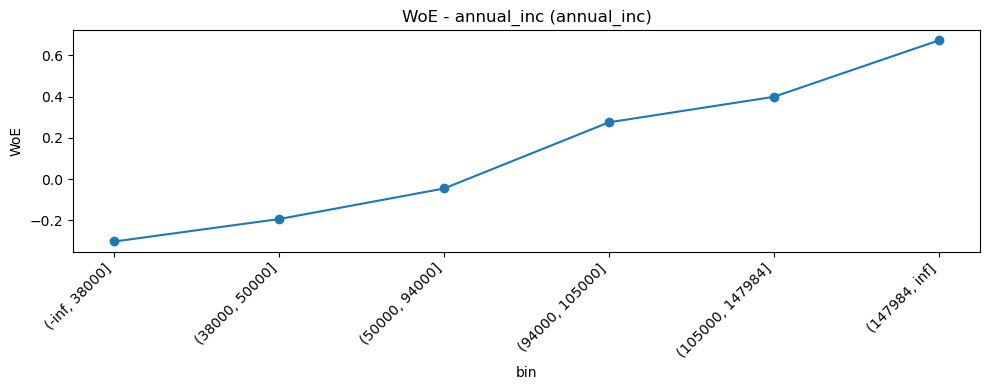

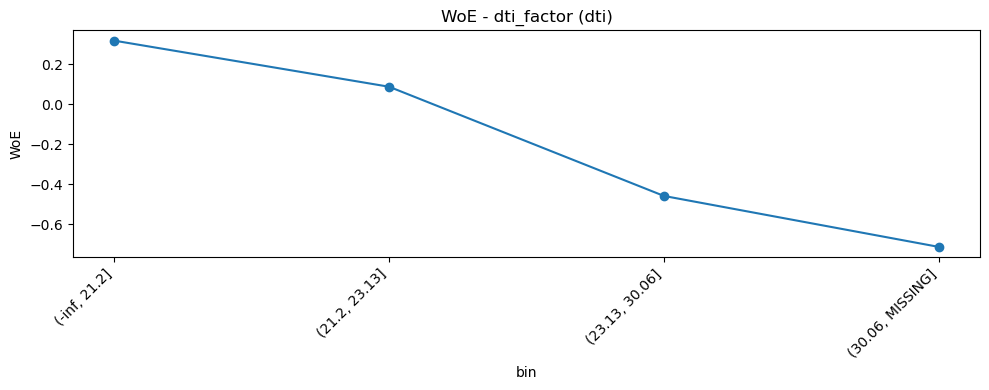

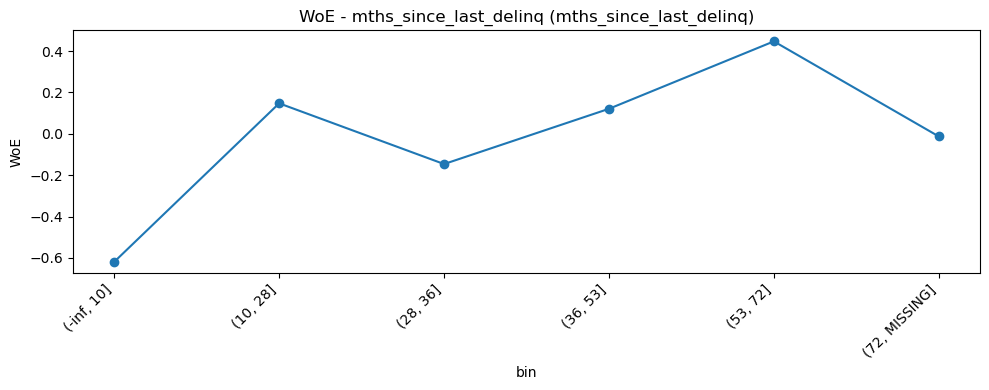

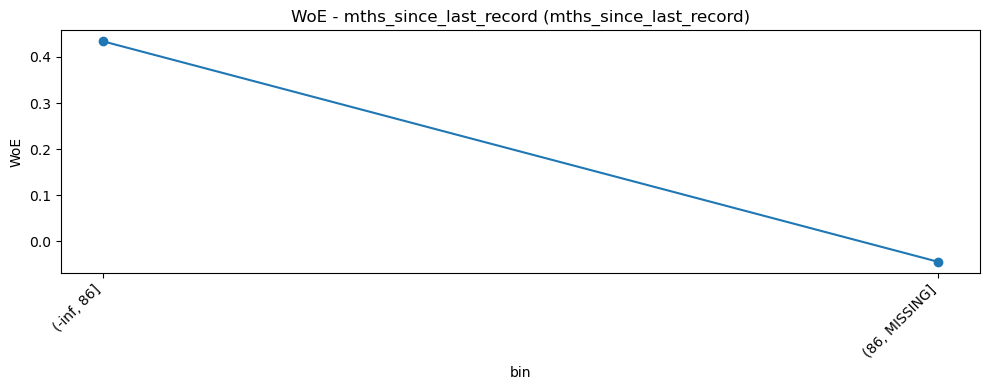

In [21]:
# Optional visual checks
for feat in ["annual_inc", "dti_factor", "mths_since_last_delinq", "mths_since_last_record"]:
    resolved = name_mapping.get(feat)
    if resolved in reports:
        plot_by_woe(reports[resolved], title=f'WoE - {feat} ({resolved})')


In [22]:
train_fe_bins = add_all_bin_indicator_columns(train_fe, pipelines, drop_grp_cols=False)
test_fe_bins = add_all_bin_indicator_columns(test_fe, pipelines, drop_grp_cols=False)

In [23]:
train_fe.select("addr_state", *[c for c in train_fe.columns if c.startswith("addr_state")]).show(20, truncate=False)

+----------+----------+--------------------+---------------------------------------------------------+---------------------+
|addr_state|addr_state|addr_state__base_grp|addr_state_grp                                           |addr_state_woe       |
+----------+----------+--------------------+---------------------------------------------------------+---------------------+
|MD        |MD        |MD                  |CT | PA | NC | MD | AL | NY                              |-0.16979160215506225 |
|IN        |IN        |IN                  |SC | AK | IN | KY | MO | AR | DC | ME | NM | WA          |-0.6451686951914078  |
|OR        |OR        |OR                  |MN | OR | TX | CO | MI | WI                              |-0.030915461969215997|
|CO        |CO        |CO                  |MN | OR | TX | CO | MI | WI                              |-0.030915461969215997|
|IL        |IL        |IL                  |NJ | MS | UT | IL | TN | GA                              |0.3631127776268814   |


## 3.5 Save Outputs


In [24]:
drop_cols_train = [
    c for c in train_fe_bins.columns
    if c.endswith("_grp") or c.endswith("_woe") or c.endswith("__base_grp")
]
drop_cols_test = [
    c for c in test_fe_bins.columns
    if c.endswith("_grp") or c.endswith("_woe") or c.endswith("__base_grp")
]

train_fe_bins = train_fe_bins.drop(*drop_cols_train)
test_fe_bins = test_fe_bins.drop(*drop_cols_test)

In [25]:
new_cols_train = [c for c in train_fe_bins.columns if c not in train_df.columns]
new_cols_test = [c for c in test_fe_bins.columns if c not in test_df.columns]

print("New columns in train_fe:")
for c in new_cols_train:
    print(c)

print("\nNew columns in test_fe:")
for c in new_cols_test:
    print(c)

New columns in train_fe:
grade_B
grade_D
grade_C
grade_A
grade_F|G|E
home_ownership_OWN
home_ownership_RENT
home_ownership_MORTGAGE
addr_state_VA|CA
addr_state_CT|PA|NC|MD|AL|NY
addr_state_MN|OR|TX|CO|MI|WI
addr_state_SC|AK|IN|KY|MO|AR|DC|ME|NM|WA
addr_state_NJ|MS|UT|IL|TN|GA
addr_state_LA|OK|NV|RI|ID|NH|WV|HI|WY|DE|NE|MT
addr_state_AZ|VT|FL|OH|MA|KS
verification_status_Verified
verification_status_SourceVerified
verification_status_NotVerified
purpose_wedding|educational|renewable_energy|car|moving|home_improvement
purpose_small_business|major_purchase|debt_consolidation|medical|vacation|house
purpose_other
purpose_credit_card
initial_list_status_f
initial_list_status_w
term_int_(36,60]
term_int_(60,inf]
emp_length_int_(10,inf]
emp_length_int_(3,5]
emp_length_int_(1,2]
emp_length_int_(2,3]
emp_length_int_(6,8]
emp_length_int_(0,1]
emp_length_int_(8,10]
emp_length_int_(5,6]
delinq_2yrs_(0,1]
delinq_2yrs_(1,inf]
inq_last_6mths_(1,2]
inq_last_6mths_(0,1]
inq_last_6mths_(2,inf]
open_acc_(

In [26]:
full_baseline = train_fe_bins.unionByName(test_fe_bins, allowMissingColumns=True)

save_parquet(train_fe_bins, '/home/jovyan/work/data/parquet/features_pd_train.parquet')
save_parquet(test_fe_bins, '/home/jovyan/work/data/parquet/features_pd_test.parquet')
save_parquet(full_baseline, '/home/jovyan/work/data/parquet/features_baseline.parquet')

# Save WoE reports for auditability
for resolved_col, rep in reports.items():
    rep.to_csv(f'/home/jovyan/work/outputs/tables/woe_report_{resolved_col}.csv', index=False)

print('Saved parquet features and WoE report CSV files.')


Saved to /home/jovyan/work/data/parquet/features_pd_train.parquet
Saved to /home/jovyan/work/data/parquet/features_pd_test.parquet
Saved to /home/jovyan/work/data/parquet/features_baseline.parquet
Saved parquet features and WoE report CSV files.
